## Inverse Area Solver


In [1]:
# Cell 1: imports

from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import vt_all_solvers_wrapper as vt
import dataset
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module
import models.back_base as back_base
import models.metropolis as metropolis_module

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)
importlib.reload(back_base)
importlib.reload(metropolis_module)

import base_range_library 
importlib.reload(base_range_library)
from base_range_library import range_library

from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionMambaFusionDeepONet,
    TransferFunctionMambaOperator,
    TransferFunctionMambaSIRENDynamicDeformableDeepONet,
)
from models.back_base import InverseAreaSolver

In [2]:
# Cell 2: config

device = "cuda" if torch.cuda.is_available() else "cpu"

# Available choices: "mlp", "fno", "deeponet", "mamba_fusion", "mamba_operator", "mamba_hybrid".
# The selected checkpoint must exist in checkpoints/.
model_choice = "mamba_hybrid"
mamba_hybrid_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"
# For the hole-finetuned version use:
# mamba_hybrid_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_hole_db"

sections = 100
n_profile_points = 128
n_frequencies = 256

f_min_hz = 50.0
f_max_hz = 5000.0

# Target sample generated by the classical cone solver.
target_geometry_kind = "random"
target_seed = 2028

# Inverse optimization parameters.
n_control_points = 10
n_inverse_steps = 5000
inverse_lr = 3e-3
log_every = 25

# Metropolis inverse parameters.
# Это второй тип обратного решения: стохастический поиск по контрольным точкам.
metropolis_n_steps = 6000
metropolis_burn_in = 1000
metropolis_thinning = 20
metropolis_proposal_std = 0.08
metropolis_temperature = 1.0

# Area bounds in physical units, m^2. Match base_range_library scale.
min_area_m2 = 1.0e-4
max_area_m2 = 5.0e-2

# Вес штрафа за первую производную log(area).
# Ограничивает общий наклон и слишком быстрые изменения площади вдоль канала.
# После деления конечной разности на dx величина smoothness возрастает,
# поэтому используется сравнительно небольшой коэффициент.
smoothness_weight = 1e-3

# Вес штрафа за вторую производную log(area).
# Подавляет локальные осцилляции, резкие изломы и "зубчатость" профиля.
# Вторая производная делится на dx**2, а затем возводится в квадрат,
# поэтому curvature имеет очень большой численный масштаб и требует
# значительно меньшего веса.
curvature_weight = 1e-8

# Вес отклонения найденного профиля от reference_area.
# Увеличивай этот вес, если профиль должен оставаться близким
# к среднему, начальному или другому известному допустимому профилю.
prior_weight = 0

torch.manual_seed(1)

print("device:", device)
print("model_choice:", model_choice)


device: cuda
model_choice: fno


In [3]:
# Cell 3: solver config and target sample

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

target_config = StreamingGeometryDatasetConfig(
    geometry_kind=target_geometry_kind,
    solver_config=solver_config,
    target_mode="db",
    seed=target_seed,
    max_samples=1,
)

target_loader = make_streaming_dataloader(
    target_config,
    range_library,
    batch_size=1,
    num_workers=0,
)

target_batch = next(iter(target_loader))

target_db = target_batch["target"].to(device).float()
frequencies_hz = target_batch["frequencies_hz"].to(device).float()

true_area_m2 = utils.make_webster_profile_features(
    target_batch,
    n_points=n_profile_points,
    log_area=False,
    include_x=False,
    channel_first=True,
    device=device,
)

print("target_db shape:", tuple(target_db.shape))
print("frequencies_hz shape:", tuple(frequencies_hz.shape))
print("true_area_m2 shape:", tuple(true_area_m2.shape))
print("target min/max dB:", float(target_db.min()), float(target_db.max()))


target_db shape: (1, 256)
frequencies_hz shape: (1, 256)
true_area_m2 shape: (1, 1, 128)
target min/max dB: -8.504549980163574 31.455780029296875


In [4]:
# Cell 4: model factory and checkpoint loading

def load_training_checkpoint(model, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    utils.load_model_state(model, state_dict, strict=True)
    model.eval()
    return checkpoint


def make_model(model_choice):
    if model_choice == "mlp":
        model = ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/mlp_db_best.pt")
        model_kind = "mlp"
        return model, checkpoint_path, model_kind

    if model_choice == "fno":
        model = TransferFunctionFNO(
            n_modes=32,
            hidden_channels=96,
            latent_dim=256,
            pooling_bins=16,
            frequency_bands=16,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/fno_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "deeponet":
        model = TransferFunctionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/deeponet_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_fusion":
        model = TransferFunctionMambaFusionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
        ).to(device)
        checkpoint_path = Path("checkpoints/mamba_fusion_deeponet_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_operator":
        model = TransferFunctionMambaOperator(
            in_channels=1,
            d_model=32,
            hidden_channels=64,
            frequency_bands=16,
            frequency_hidden_dim=128,
            mamba_backend="minimal_mamba2",
            mamba_depth=2,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=16,
            mamba_headdim=32,
            mamba_chunk_size=32,
            dropout=0.0,
            out_channels=1,
            frequency_chunk_size=8,
        ).to(device)
        checkpoint_path = Path("checkpoints/mamba_operator_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_hybrid":
        model = TransferFunctionMambaSIRENDynamicDeformableDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            trunk_hidden_dim=128,
            trunk_hidden_layers=3,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            out_channels=1,
            n_experts=4,
            routing_hidden_dim=32,
            temperature=1.0,
            max_offset=2.0,
            offset_hidden_channels=32,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
            warm_start_verbose=False,
        ).to(device)
        checkpoint_path = Path("checkpoints") / f"{mamba_hybrid_checkpoint_name}_best.pt"
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    raise ValueError(
        "model_choice must be one of: "
        "'mlp', 'fno', 'deeponet', 'mamba_fusion', "
        "'mamba_operator', 'mamba_hybrid'"
    )


model, checkpoint_path, model_kind = make_model(model_choice)
checkpoint = load_training_checkpoint(model, checkpoint_path)

print("loaded checkpoint:", checkpoint_path)
print("model_kind:", model_kind)
print("model parameters:", utils.count_parameters(model))


loaded checkpoint: checkpoints/fno_db_best.pt
model_kind: operator
model parameters: 1405633


In [5]:
# Cell 5: quick forward check on the true geometry

with torch.inference_mode():
    if model_kind == "mlp":
        true_input = back_base.mlp_profile_input(
            true_area_m2,
            log_area=True,
            include_x=True,
        )
        surrogate_on_true = model(true_input)
    else:
        true_input = back_base.operator_area_input(
            true_area_m2,
            log_area=True,
        )
        kappa = back_base.make_kappa(
            frequencies_hz,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )
        surrogate_on_true = model(true_input, kappa)

true_surrogate_mse = torch.mean((surrogate_on_true - target_db) ** 2)
print("surrogate(target geometry) MSE:", float(true_surrogate_mse))
print("surrogate output shape:", tuple(surrogate_on_true.shape))


surrogate(target geometry) MSE: 11.496400833129883
surrogate output shape: (1, 256)


In [6]:
# Cell 6: inverse optimization, method 1: gradient

inverse_solver = InverseAreaSolver(
    model,
    model_kind=model_kind,
    log_area=True,
    include_x=True,
)

solution = inverse_solver.solve(
    target=target_db,
    frequencies_hz=frequencies_hz,
    n_points=n_profile_points,
    n_control_points=n_control_points,
    min_area_m2=min_area_m2,
    max_area_m2=max_area_m2,
    n_steps=n_inverse_steps,
    learning_rate=inverse_lr,
    smoothness_weight=smoothness_weight,
    curvature_weight=curvature_weight,
    prior_weight=prior_weight,
    gradient_clip_norm=10.0,
    log_every=log_every,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
)

print("best total loss:", solution.total_loss)
print("best transfer loss:", solution.transfer_loss)
print("optimized area shape:", tuple(solution.area_m2.shape))

last_metrics = solution.history[-1]

print(
    "Inverse optimization metrics:\n"
    f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
    f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
    f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
    f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
    f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
)


gradient_solution = solution


best total loss: 11.288799285888672
best transfer loss: 11.270312309265137
optimized area shape: (1, 1, 128)
Inverse optimization metrics:
  total_loss:          1.128880e+01
  transfer_loss:       1.127031e+01
  weighted_smoothness: 1.814806e-02
  weighted_curvature:  3.387577e-04
  weighted_prior:      0.000000e+00


## Метод Метрополиса


In [ ]:
# Inverse optimization, method 2: metropolis


def make_metropolis_profile_fn(
    *,
    n_points,
    min_area_m2,
    max_area_m2,
    fixed_inlet_area_m2=None,
    fixed_outlet_area_m2=None,
):
    def profile_fn(parameters):
        if parameters.ndim != 2:
            raise ValueError(
                "parameters must have shape [B, M], "
                f"got {tuple(parameters.shape)}"
            )

        control = min_area_m2 + (max_area_m2 - min_area_m2) * torch.sigmoid(
            parameters[:, None, :]
        )
        area = F.interpolate(
            control,
            size=n_points,
            mode="linear",
            align_corners=True,
        )

        if fixed_inlet_area_m2 is not None:
            inlet = torch.full_like(area[..., :1], float(fixed_inlet_area_m2))
            area = torch.cat([inlet, area[..., 1:]], dim=-1)

        if fixed_outlet_area_m2 is not None:
            outlet = torch.full_like(area[..., -1:], float(fixed_outlet_area_m2))
            area = torch.cat([area[..., :-1], outlet], dim=-1)

        return area

    return profile_fn


def area_to_initial_metropolis_parameters(
    area_m2,
    *,
    n_control_points,
    min_area_m2,
    max_area_m2,
):
    if area_m2.ndim == 2:
        area_m2 = area_m2.unsqueeze(1)
    if area_m2.ndim != 3:
        raise ValueError(
            "area_m2 must have shape [B, 1, Nx] or [B, Nx], "
            f"got {tuple(area_m2.shape)}"
        )

    control = F.interpolate(
        area_m2,
        size=n_control_points,
        mode="linear",
        align_corners=True,
    )
    normalized = (
        (control - min_area_m2)
        / (max_area_m2 - min_area_m2)
    ).clamp(1.0e-5, 1.0 - 1.0e-5)

    return torch.logit(normalized).squeeze(1)


metropolis_profile_fn = make_metropolis_profile_fn(
    n_points=n_profile_points,
    min_area_m2=min_area_m2,
    max_area_m2=max_area_m2,
)

# Start from the middle of the admissible area range.
# To start from the true/known initial profile, replace this with
# area_to_initial_metropolis_parameters(...).
metropolis_initial_parameters = torch.zeros(
    1,
    n_control_points,
    device=device,
)

metropolis_result = metropolis_inverse_for_project_model(
    model=model,
    target=target_db,
    frequencies_hz=frequencies_hz,
    initial_parameters=metropolis_initial_parameters,
    profile_fn=metropolis_profile_fn,
    transfer_loss_fn=back_base.transfer_mse_loss,
    model_kind=model_kind,
    log_area=True,
    include_x=True,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
    n_steps=metropolis_n_steps,
    burn_in=metropolis_burn_in,
    thinning=metropolis_thinning,
    proposal_std=metropolis_proposal_std,
    temperature=metropolis_temperature,
)

print("metropolis best loss:", metropolis_result.best_loss)
print("metropolis accepted fraction:", metropolis_result.accepted_fraction)
print("metropolis samples shape:", tuple(metropolis_result.samples.shape))
print("metropolis best area shape:", tuple(metropolis_result.best_area.shape))


In [ ]:
# Metropolis diagnostics

metropolis_losses = metropolis_result.losses.detach().cpu().numpy().reshape(-1)
metropolis_sample_index = np.arange(len(metropolis_losses))

plt.figure(figsize=(10, 4))
plt.plot(metropolis_sample_index, metropolis_losses, linewidth=1.6)
plt.xlabel("stored sample")
plt.ylabel("transfer loss")
plt.title("Metropolis stored-sample loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


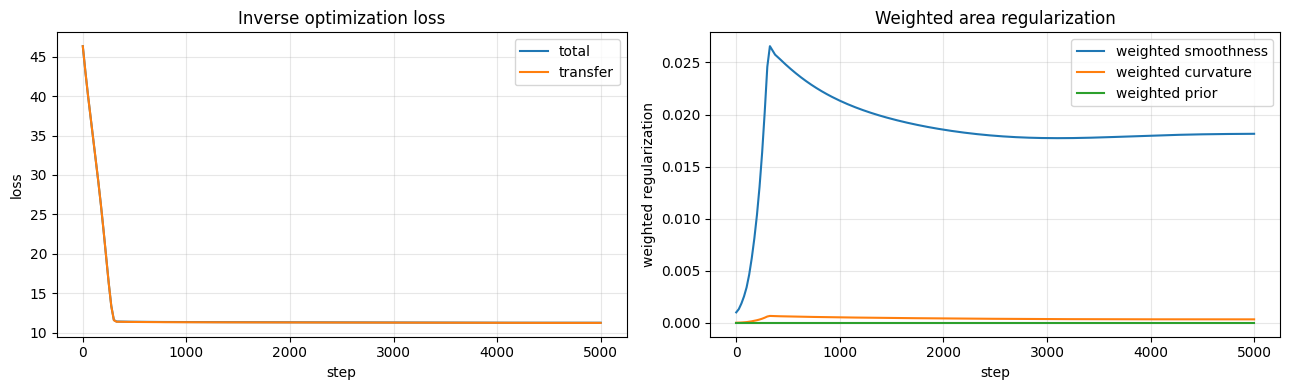

In [7]:
# Cell 7: loss curves

history = solution.history
steps = [row["step"] for row in history]

def hist(name):
    return [row[name] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps, hist("total_loss"), label="total")
axes[0].plot(steps, hist("transfer_loss"), label="transfer")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].set_title("Gradient inverse optimization loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(steps, hist("weighted_smoothness"), label="weighted smoothness")
axes[1].plot(steps, hist("weighted_curvature"), label="weighted curvature")
axes[1].plot(steps, hist("weighted_prior"), label="weighted prior")
axes[1].set_xlabel("step")
axes[1].set_ylabel("weighted regularization")
axes[1].set_title("Weighted area regularization")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


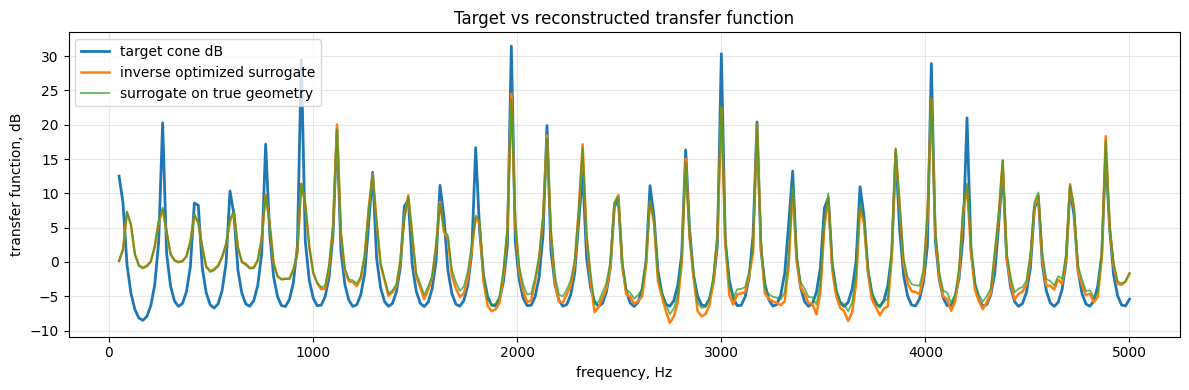

inverse surrogate MAE dB: 2.3380472660064697
inverse surrogate RMSE dB: 3.357128620147705


In [8]:
# Cell 8: target vs inverse surrogate prediction

freq = frequencies_hz[0].detach().cpu().numpy()
target_np = target_db[0].detach().cpu().numpy()
pred_np = solution.prediction[0].detach().cpu().numpy()
true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(freq, target_np, linewidth=2.0, label="target cone dB")
plt.plot(freq, pred_np, linewidth=1.8, label="inverse optimized surrogate")
plt.plot(freq, true_surrogate_np, linewidth=1.3, alpha=0.75, label="surrogate on true geometry")
plt.xlabel("frequency, Hz")
plt.ylabel("transfer function, dB")
plt.title("Gradient inverse: target vs reconstructed transfer function")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(pred_np - target_np))
rmse = np.sqrt(np.mean((pred_np - target_np) ** 2))
print("inverse surrogate MAE dB:", float(mae))
print("inverse surrogate RMSE dB:", float(rmse))


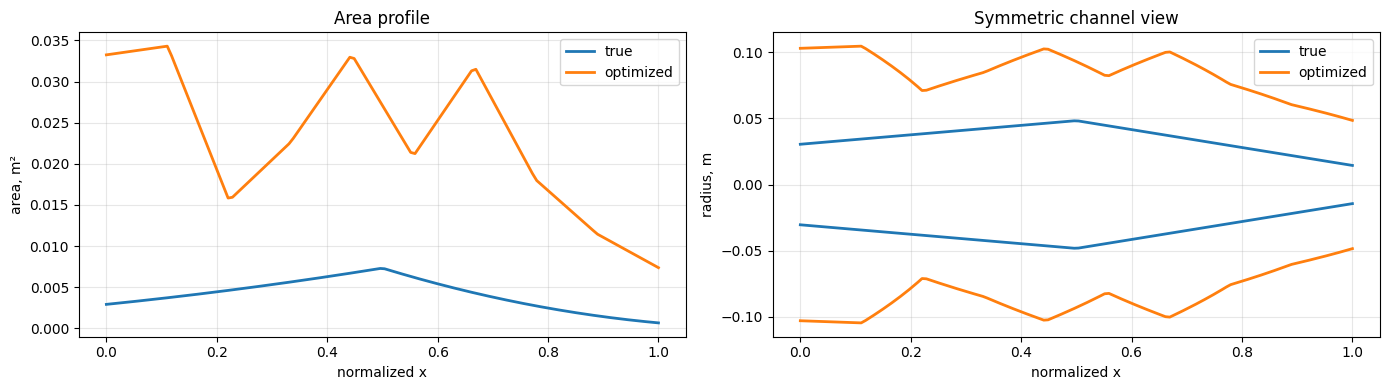

relative area L2: 4.455423355102539


In [9]:
# Cell 9: true vs optimized geometry

x = np.linspace(0.0, 1.0, n_profile_points)
true_area = true_area_m2[0, 0].detach().cpu().numpy()
opt_area = solution.area_m2[0, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x, true_area, linewidth=2.0, label="true")
axes[0].plot(x, opt_area, linewidth=2.0, label="optimized")
axes[0].set_xlabel("normalized x")
axes[0].set_ylabel("area, m²")
axes[0].set_title("Gradient inverse area profile")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

true_radius = np.sqrt(true_area / np.pi)
opt_radius = np.sqrt(opt_area / np.pi)

axes[1].plot(x, true_radius, color="tab:blue", linewidth=2.0, label="true")
axes[1].plot(x, -true_radius, color="tab:blue", linewidth=2.0)
axes[1].plot(x, opt_radius, color="tab:orange", linewidth=2.0, label="optimized")
axes[1].plot(x, -opt_radius, color="tab:orange", linewidth=2.0)
axes[1].set_xlabel("normalized x")
axes[1].set_ylabel("radius, m")
axes[1].set_title("Symmetric channel view")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

rel_area_l2 = np.linalg.norm(opt_area - true_area) / max(np.linalg.norm(true_area), 1e-12)
print("relative area L2:", float(rel_area_l2))


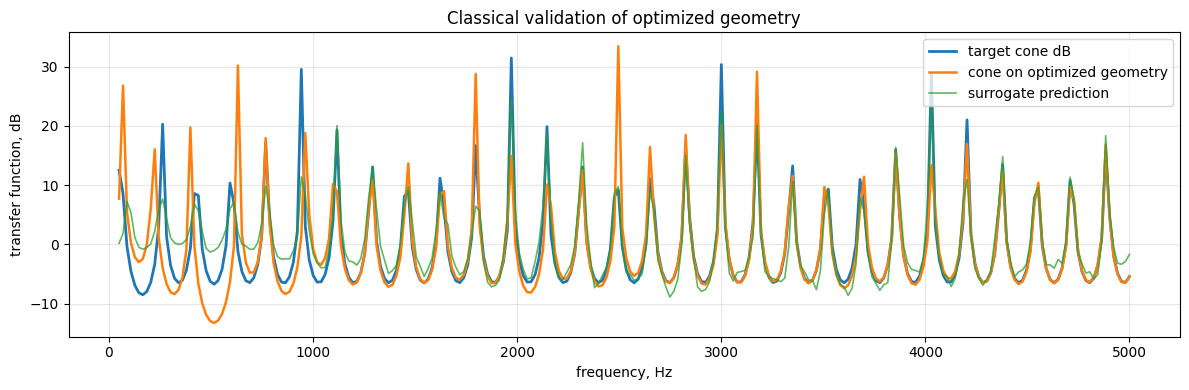

cone validation MAE dB: 2.614585322799968
cone validation RMSE dB: 5.4309409739502925


In [10]:
# Cell 10: optional validation by classical cone solver on optimized geometry

optimized_geometry = vt.ExplicitGeometry(
    x_m=x.tolist(),
    area_m2=opt_area.tolist(),
)

optimized_result = vt.solve(
    optimized_geometry,
    config=solver_config,
)

optimized_cone_db = 20.0 * np.log10(np.maximum(np.asarray(optimized_result.magnitude), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(freq, target_np, linewidth=2.0, label="target cone dB")
plt.plot(freq, optimized_cone_db, linewidth=1.8, label="cone on optimized geometry")
plt.plot(freq, pred_np, linewidth=1.2, alpha=0.75, label="surrogate prediction")
plt.xlabel("frequency, Hz")
plt.ylabel("transfer function, dB")
plt.title("Classical validation of gradient optimized geometry")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mae_cone = np.mean(np.abs(optimized_cone_db - target_np))
rmse_cone = np.sqrt(np.mean((optimized_cone_db - target_np) ** 2))
print("cone validation MAE dB:", float(mae_cone))
print("cone validation RMSE dB:", float(rmse_cone))


## Сравнение двух обратных решений


In [ ]:
# Comparison of inverse methods

freq = frequencies_hz[0].detach().cpu().numpy()
target_np = target_db[0].detach().cpu().numpy()
true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

gradient_prediction_np = gradient_solution.prediction[0].detach().cpu().numpy()
metropolis_prediction_np = metropolis_result.best_prediction[0].detach().cpu().numpy()

true_area_np = true_area_m2[0, 0].detach().cpu().numpy()
gradient_area_np = gradient_solution.area_m2[0, 0].detach().cpu().numpy()
metropolis_area_np = metropolis_result.best_area[0, 0].detach().cpu().numpy()

x = np.linspace(0.0, 1.0, n_profile_points)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].plot(freq, target_np, color="black", linewidth=2.4, label="target cone dB")
axes[0].plot(freq, gradient_prediction_np, linewidth=1.8, label="gradient inverse")
axes[0].plot(freq, metropolis_prediction_np, linewidth=1.8, label="metropolis inverse")
axes[0].plot(freq, true_surrogate_np, linewidth=1.2, alpha=0.7, label="surrogate on true geometry")
axes[0].set_xlabel("frequency, Hz")
axes[0].set_ylabel("transfer function, dB")
axes[0].set_title("Transfer function comparison")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, true_area_np, color="black", linewidth=2.4, label="true")
axes[1].plot(x, gradient_area_np, linewidth=1.8, label="gradient inverse")
axes[1].plot(x, metropolis_area_np, linewidth=1.8, label="metropolis inverse")
axes[1].set_xlabel("normalized x")
axes[1].set_ylabel("area, m²")
axes[1].set_title("Area profile comparison")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


def prediction_metrics(prediction_np, target_np):
    return {
        "mae_db": float(np.mean(np.abs(prediction_np - target_np))),
        "rmse_db": float(np.sqrt(np.mean((prediction_np - target_np) ** 2))),
    }


def area_rel_l2(area_np, true_area_np):
    return float(
        np.linalg.norm(area_np - true_area_np)
        / max(np.linalg.norm(true_area_np), 1.0e-12)
    )

comparison_rows = [
    {
        "method": "gradient",
        **prediction_metrics(gradient_prediction_np, target_np),
        "area_rel_l2": area_rel_l2(gradient_area_np, true_area_np),
        "accepted_fraction": np.nan,
    },
    {
        "method": "metropolis",
        **prediction_metrics(metropolis_prediction_np, target_np),
        "area_rel_l2": area_rel_l2(metropolis_area_np, true_area_np),
        "accepted_fraction": float(metropolis_result.accepted_fraction),
    },
]

print("=== Inverse method comparison ===")
print(f"{'method':12s} | {'MAE dB':>10s} | {'RMSE dB':>10s} | {'area rel L2':>12s} | {'accept':>8s}")
print("-" * 66)
for row in comparison_rows:
    accept = "-" if np.isnan(row["accepted_fraction"]) else f"{row['accepted_fraction']:.3f}"
    print(
        f"{row['method']:12s} | "
        f"{row['mae_db']:10.4f} | "
        f"{row['rmse_db']:10.4f} | "
        f"{row['area_rel_l2']:12.4f} | "
        f"{accept:>8s}"
    )


## Сoarse-to-fine

In [11]:
# Coarse-to-fine inverse optimization

stages = [
    {
        "n_control_points": 4,
        "n_steps": 1500,
        "learning_rate": 3e-3,
        "smoothness_weight": 1e-4,
        "curvature_weight": 1e-8,
        "prior_weight": 0.0,
    },
    {
        "n_control_points": 8,
        "n_steps": 1500,
        "learning_rate": 2e-3,
        "smoothness_weight": 5e-5,
        "curvature_weight": 5e-9,
        "prior_weight": 0.0,
    },
    {
        "n_control_points": 16,
        "n_steps": 2000,
        "learning_rate": 1e-3,
        "smoothness_weight": 2e-5,
        "curvature_weight": 2e-9,
        "prior_weight": 0.0,
    },
]

all_solutions = []
initial_area_m2 = None

for stage_idx, stage in enumerate(stages, start=1):
    print(f"\n=== Stage {stage_idx}: {stage['n_control_points']} control points ===")

    solution = inverse_solver.solve(
        target=target_db,
        frequencies_hz=frequencies_hz,
        n_points=n_profile_points,
        n_control_points=stage["n_control_points"],
        min_area_m2=min_area_m2,
        max_area_m2=max_area_m2,
        initial_area_m2=initial_area_m2,
        n_steps=stage["n_steps"],
        learning_rate=stage["learning_rate"],
        smoothness_weight=stage["smoothness_weight"],
        curvature_weight=stage["curvature_weight"],
        prior_weight=stage["prior_weight"],
        gradient_clip_norm=10.0,
        log_every=log_every,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
    )

    all_solutions.append(solution)
    initial_area_m2 = solution.area_m2.detach()

    last_metrics = solution.history[-1]
    print(
        f"stage {stage_idx} done:\n"
        f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
        f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
        f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
        f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
        f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
    )

solution = all_solutions[-1]


=== Stage 1: 4 control points ===


stage 1 done:
  total_loss:          1.175399e+01
  transfer_loss:       1.175342e+01
  weighted_smoothness: 5.550223e-04
  weighted_curvature:  1.998600e-05
  weighted_prior:      0.000000e+00

=== Stage 2: 8 control points ===
stage 2 done:
  total_loss:          1.116161e+01
  transfer_loss:       1.116043e+01
  weighted_smoothness: 1.148706e-03
  weighted_curvature:  3.699716e-05
  weighted_prior:      0.000000e+00

=== Stage 3: 16 control points ===
stage 3 done:
  total_loss:          1.102547e+01
  transfer_loss:       1.102217e+01
  weighted_smoothness: 2.383435e-03
  weighted_curvature:  9.205265e-04
  weighted_prior:      0.000000e+00


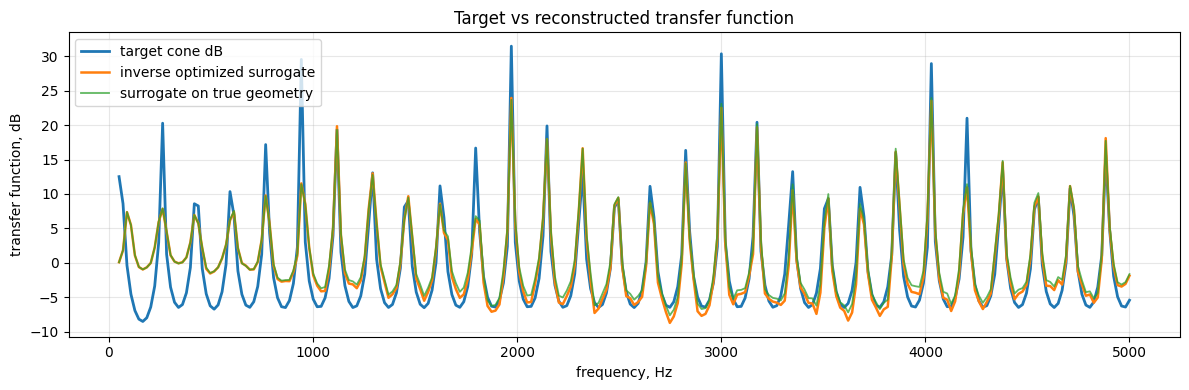

inverse surrogate MAE dB: 2.297333240509033
inverse surrogate RMSE dB: 3.319965124130249


In [12]:
freq = frequencies_hz[0].detach().cpu().numpy()
target_np = target_db[0].detach().cpu().numpy()
pred_np = solution.prediction[0].detach().cpu().numpy()
true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(freq, target_np, linewidth=2.0, label="target cone dB")
plt.plot(freq, pred_np, linewidth=1.8, label="inverse optimized surrogate")
plt.plot(freq, true_surrogate_np, linewidth=1.3, alpha=0.75, label="surrogate on true geometry")
plt.xlabel("frequency, Hz")
plt.ylabel("transfer function, dB")
plt.title("Target vs reconstructed transfer function")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(pred_np - target_np))
rmse = np.sqrt(np.mean((pred_np - target_np) ** 2))
print("inverse surrogate MAE dB:", float(mae))
print("inverse surrogate RMSE dB:", float(rmse))

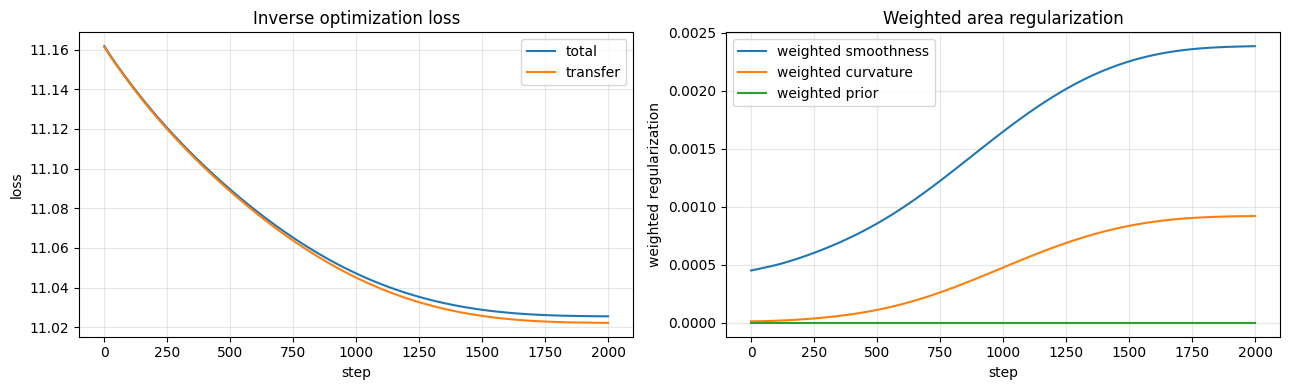

In [13]:
history = solution.history
steps = [row["step"] for row in history]

def hist(name):
    return [row[name] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps, hist("total_loss"), label="total")
axes[0].plot(steps, hist("transfer_loss"), label="transfer")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].set_title("Inverse optimization loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(steps, hist("weighted_smoothness"), label="weighted smoothness")
axes[1].plot(steps, hist("weighted_curvature"), label="weighted curvature")
axes[1].plot(steps, hist("weighted_prior"), label="weighted prior")
axes[1].set_xlabel("step")
axes[1].set_ylabel("weighted regularization")
axes[1].set_title("Weighted area regularization")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


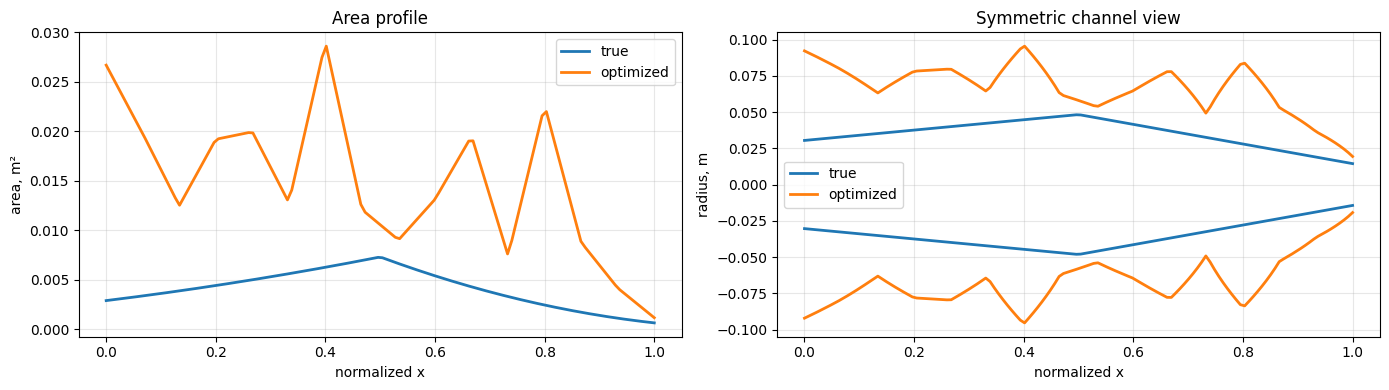

relative area L2: 2.6863152980804443


In [14]:
x = np.linspace(0.0, 1.0, n_profile_points)
true_area = true_area_m2[0, 0].detach().cpu().numpy()
opt_area = solution.area_m2[0, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x, true_area, linewidth=2.0, label="true")
axes[0].plot(x, opt_area, linewidth=2.0, label="optimized")
axes[0].set_xlabel("normalized x")
axes[0].set_ylabel("area, m²")
axes[0].set_title("Area profile")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

true_radius = np.sqrt(true_area / np.pi)
opt_radius = np.sqrt(opt_area / np.pi)

axes[1].plot(x, true_radius, color="tab:blue", linewidth=2.0, label="true")
axes[1].plot(x, -true_radius, color="tab:blue", linewidth=2.0)
axes[1].plot(x, opt_radius, color="tab:orange", linewidth=2.0, label="optimized")
axes[1].plot(x, -opt_radius, color="tab:orange", linewidth=2.0)
axes[1].set_xlabel("normalized x")
axes[1].set_ylabel("radius, m")
axes[1].set_title("Symmetric channel view")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

rel_area_l2 = np.linalg.norm(opt_area - true_area) / max(np.linalg.norm(true_area), 1e-12)
print("relative area L2:", float(rel_area_l2))


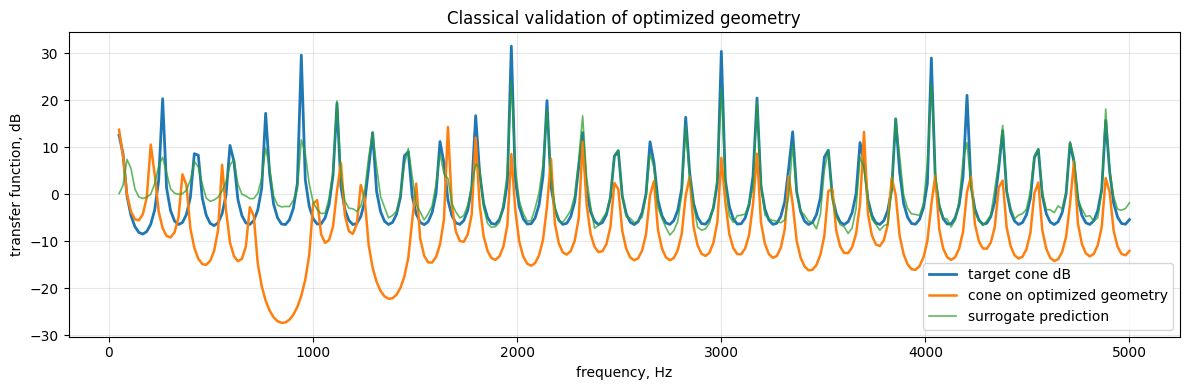

cone validation MAE dB: 9.13181553730884
cone validation RMSE dB: 11.388419825752354


In [15]:
# Cell 10: optional validation by classical cone solver on optimized geometry

optimized_geometry = vt.ExplicitGeometry(
    x_m=x.tolist(),
    area_m2=opt_area.tolist(),
)

optimized_result = vt.solve(
    optimized_geometry,
    config=solver_config,
)

optimized_cone_db = 20.0 * np.log10(np.maximum(np.asarray(optimized_result.magnitude), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(freq, target_np, linewidth=2.0, label="target cone dB")
plt.plot(freq, optimized_cone_db, linewidth=1.8, label="cone on optimized geometry")
plt.plot(freq, pred_np, linewidth=1.2, alpha=0.75, label="surrogate prediction")
plt.xlabel("frequency, Hz")
plt.ylabel("transfer function, dB")
plt.title("Classical validation of optimized geometry")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mae_cone = np.mean(np.abs(optimized_cone_db - target_np))
rmse_cone = np.sqrt(np.mean((optimized_cone_db - target_np) ** 2))
print("cone validation MAE dB:", float(mae_cone))
print("cone validation RMSE dB:", float(rmse_cone))


## Find a hole

hole target shape: (1, 256)
straight initial area shape: (1, 1, 128)
hole area min/max: 0.0001767145877238363 0.021382464095950127
straight area: 0.0001767145877238363


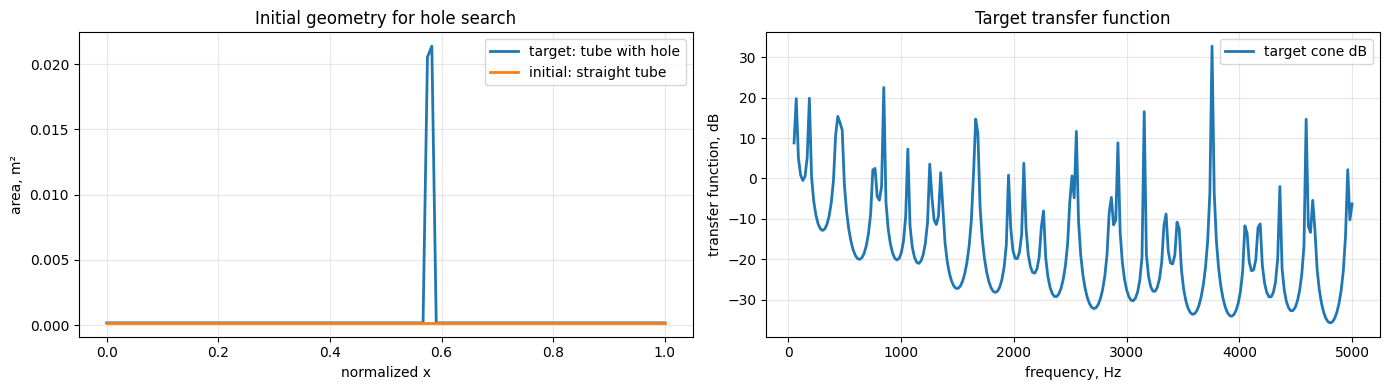


=== Find-hole stage 1: 10 control points ===
stage metrics:
  total_loss:          2.553995e+00
  transfer_loss:       2.545802e+00
  weighted_smoothness: 6.305796e-03
  weighted_curvature:  1.887774e-03
  weighted_prior:      0.000000e+00

=== Find-hole stage 2: 20 control points ===
stage metrics:
  total_loss:          1.969552e+00
  transfer_loss:       1.959831e+00
  weighted_smoothness: 7.505727e-03
  weighted_curvature:  2.215851e-03
  weighted_prior:      0.000000e+00


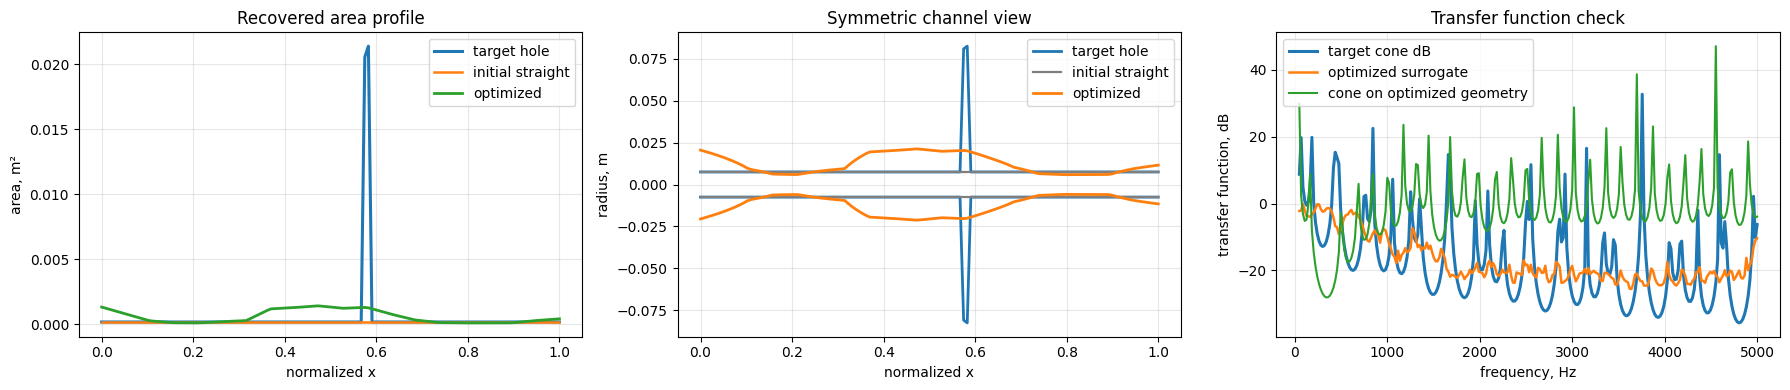

find-hole relative area L2: 0.9650433659553528
find-hole surrogate MAE dB: 8.680997848510742
find-hole cone validation MAE dB: 20.161032787024602


In [32]:
# Find a hole in a straight tube
#
# Goal:
#   1. Create a target tube with a local hole / expansion.
#   2. Create a straight tube with the same base area.
#   3. Use the straight tube as initial_area_m2 for inverse optimization.
#   4. Check whether the optimized geometry recovers the hole.

hole_length_m = 1.0
hole_base_width_m = 0.015
hole_base_area_m2 = np.pi * (0.5 * hole_base_width_m) ** 2
hole_center_m = 0.58

# Use the project default hole geometry: hole_width_m, hole_height_m,
# hole_area_gain_m2 and transition_width_m are intentionally not passed.
# vt.make_tube_with_hole_geometry defines them relative to the tube itself.
hole_geometry = vt.make_tube_with_hole_geometry(
    length_m=hole_length_m,
    base_width_m=hole_base_width_m,
    hole_center_m=hole_center_m,
)

straight_geometry = vt.make_cylinder_geometry(
    length_m=hole_length_m,
    area_m2=hole_base_area_m2,
)


def geometry_to_area_tensor(geometry, *, n_points, device):
    x_m, area_m2 = vt.geometry_to_arrays(geometry)
    batch = {
        "geometry": {
            "x_m": torch.tensor([x_m], dtype=torch.float32),
            "area_m2": torch.tensor([area_m2], dtype=torch.float32),
            "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
        }
    }

    return utils.make_webster_profile_features(
        batch,
        n_points=n_points,
        log_area=False,
        include_x=False,
        channel_first=True,
        device=device,
    )


hole_area_m2 = geometry_to_area_tensor(
    hole_geometry,
    n_points=n_profile_points,
    device=device,
)

straight_area_m2 = geometry_to_area_tensor(
    straight_geometry,
    n_points=n_profile_points,
    device=device,
)

hole_result = vt.solve(
    hole_geometry,
    config=solver_config,
)

hole_target_db_np = 20.0 * np.log10(
    np.maximum(np.asarray(hole_result.magnitude, dtype=np.float32), 1e-12)
)

hole_target_db = torch.tensor(
    hole_target_db_np,
    dtype=torch.float32,
    device=device,
).unsqueeze(0)

hole_frequencies_hz = torch.tensor(
    hole_result.frequencies_hz,
    dtype=torch.float32,
    device=device,
).unsqueeze(0)

print("hole target shape:", tuple(hole_target_db.shape))
print("straight initial area shape:", tuple(straight_area_m2.shape))
print("hole area min/max:", float(hole_area_m2.min()), float(hole_area_m2.max()))
print("straight area:", float(straight_area_m2[0, 0, 0]))


from losses import UniversalTransferFunctionLoss

hole_super_loss = UniversalTransferFunctionLoss(
    output_type="db",
    db_weight=1.0,
    magnitude_weight=0.1,
    db_derivative_weight=0.05,
    peak_weight=0.0,
)

hole_frequencies_for_loss = hole_frequencies_hz[0].detach()

def hole_inverse_super_loss(prediction, target):
    return hole_super_loss(
        prediction,
        target,
        hole_frequencies_for_loss,
    )


inverse_solver = InverseAreaSolver(
    model,
    model_kind=model_kind,
    log_area=True,
    include_x=True,
    transfer_loss_fn=hole_inverse_super_loss,
)



# Quick sanity plot before inverse optimization.
x_plot = np.linspace(0.0, 1.0, n_profile_points)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    x_plot,
    hole_area_m2[0, 0].detach().cpu().numpy(),
    linewidth=2.0,
    label="target: tube with hole",
)
axes[0].plot(
    x_plot,
    straight_area_m2[0, 0].detach().cpu().numpy(),
    linewidth=2.0,
    label="initial: straight tube",
)
axes[0].set_xlabel("normalized x")
axes[0].set_ylabel("area, m²")
axes[0].set_title("Initial geometry for hole search")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(
    hole_result.frequencies_hz,
    hole_target_db_np,
    linewidth=2.0,
    label="target cone dB",
)
axes[1].set_xlabel("frequency, Hz")
axes[1].set_ylabel("transfer function, dB")
axes[1].set_title("Target transfer function")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Coarse-to-fine helps because early stages cannot create high-frequency
# oscillations in the profile. The straight tube is used as initialization
# for stage 1; every next stage starts from the previous optimized profile.
hole_stages = [
    # {
    #     "n_control_points": 4,
    #     "n_steps": 1500,
    #     "learning_rate": 3e-3,
    #     "smoothness_weight": 1e-4,
    #     "curvature_weight": 1e-8,
    #     "prior_weight": 0.0,
    #     "reference_area_m2": None,
    # },
    {
        "n_control_points": 10,
        "n_steps": 1500,
        "learning_rate": 2e-3,
        "smoothness_weight": 7e-5,
        "curvature_weight": 7e-9,
        "prior_weight": 0.0,
        "reference_area_m2": None,
    },
    {
        "n_control_points": 20,
        "n_steps": 2000,
        "learning_rate": 1e-3,
        "smoothness_weight": 5e-5,
        "curvature_weight": 5e-9,
        "prior_weight": 0.0,
        "reference_area_m2": None,
    },
    # {
    #     "n_control_points": 50,
    #     "n_steps": 2000,
    #     "learning_rate": 1e-3,
    #     "smoothness_weight": 5e-7,
    #     "curvature_weight": 5e-11,
    #     "prior_weight": 0.0,
    #     "reference_area_m2": None,
    # },
]

hole_solutions = []
initial_area_m2 = straight_area_m2.detach()

for stage_idx, stage in enumerate(hole_stages, start=1):
    print(
        f"\n=== Find-hole stage {stage_idx}: "
        f"{stage['n_control_points']} control points ==="
    )

    hole_solution = inverse_solver.solve(
        target=hole_target_db,
        frequencies_hz=hole_frequencies_hz,
        n_points=n_profile_points,
        n_control_points=stage["n_control_points"],
        min_area_m2=min_area_m2,
        max_area_m2=max_area_m2,
        initial_area_m2=initial_area_m2,
        reference_area_m2=stage["reference_area_m2"],
        n_steps=stage["n_steps"],
        learning_rate=stage["learning_rate"],
        smoothness_weight=stage["smoothness_weight"],
        curvature_weight=stage["curvature_weight"],
        prior_weight=stage["prior_weight"],
        gradient_clip_norm=10.0,
        log_every=log_every,
        initialization_noise=0.05,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
    )

    hole_solutions.append(hole_solution)
    initial_area_m2 = hole_solution.area_m2.detach()

    last_metrics = hole_solution.history[-1]
    print(
        "stage metrics:\n"
        f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
        f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
        f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
        f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
        f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
    )

hole_solution = hole_solutions[-1]
hole_optimized_area = hole_solution.area_m2[0, 0].detach().cpu().numpy()
hole_prediction_db = hole_solution.prediction[0].detach().cpu().numpy()

# Validate the optimized profile by running the classical cone solver on it.
hole_optimized_geometry = vt.ExplicitGeometry(
    x_m=x_plot.tolist(),
    area_m2=hole_optimized_area.tolist(),
)

hole_optimized_cone_result = vt.solve(
    hole_optimized_geometry,
    config=solver_config,
)

hole_optimized_cone_db = 20.0 * np.log10(
    np.maximum(np.asarray(hole_optimized_cone_result.magnitude), 1e-12)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(
    x_plot,
    hole_area_m2[0, 0].detach().cpu().numpy(),
    linewidth=2.2,
    label="target hole",
)
axes[0].plot(
    x_plot,
    straight_area_m2[0, 0].detach().cpu().numpy(),
    linewidth=1.8,
    label="initial straight",
)
axes[0].plot(
    x_plot,
    hole_optimized_area,
    linewidth=2.0,
    label="optimized",
)
axes[0].set_xlabel("normalized x")
axes[0].set_ylabel("area, m²")
axes[0].set_title("Recovered area profile")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

hole_true_radius = np.sqrt(hole_area_m2[0, 0].detach().cpu().numpy() / np.pi)
hole_init_radius = np.sqrt(straight_area_m2[0, 0].detach().cpu().numpy() / np.pi)
hole_opt_radius = np.sqrt(hole_optimized_area / np.pi)

axes[1].plot(x_plot, hole_true_radius, linewidth=2.0, color="tab:blue", label="target hole")
axes[1].plot(x_plot, -hole_true_radius, linewidth=2.0, color="tab:blue")
axes[1].plot(x_plot, hole_init_radius, linewidth=1.6, color="tab:gray", label="initial straight")
axes[1].plot(x_plot, -hole_init_radius, linewidth=1.6, color="tab:gray")
axes[1].plot(x_plot, hole_opt_radius, linewidth=2.0, color="tab:orange", label="optimized")
axes[1].plot(x_plot, -hole_opt_radius, linewidth=2.0, color="tab:orange")
axes[1].set_xlabel("normalized x")
axes[1].set_ylabel("radius, m")
axes[1].set_title("Symmetric channel view")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(
    hole_result.frequencies_hz,
    hole_target_db_np,
    linewidth=2.2,
    label="target cone dB",
)
axes[2].plot(
    hole_result.frequencies_hz,
    hole_prediction_db,
    linewidth=1.8,
    label="optimized surrogate",
)
axes[2].plot(
    hole_result.frequencies_hz,
    hole_optimized_cone_db,
    linewidth=1.5,
    label="cone on optimized geometry",
)
axes[2].set_xlabel("frequency, Hz")
axes[2].set_ylabel("transfer function, dB")
axes[2].set_title("Transfer function check")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

hole_area_rel_l2 = np.linalg.norm(
    hole_optimized_area - hole_area_m2[0, 0].detach().cpu().numpy()
) / max(np.linalg.norm(hole_area_m2[0, 0].detach().cpu().numpy()), 1e-12)

hole_surrogate_mae = np.mean(np.abs(hole_prediction_db - hole_target_db_np))
hole_cone_mae = np.mean(np.abs(hole_optimized_cone_db - hole_target_db_np))

print("find-hole relative area L2:", float(hole_area_rel_l2))
print("find-hole surrogate MAE dB:", float(hole_surrogate_mae))
print("find-hole cone validation MAE dB:", float(hole_cone_mae))
